**1. Load clean data**
***

In [2]:
import polars as pl

df = pl.read_parquet("../data/panel_merged.parquet")
display(df)


site_id,richting,datetime,cyclist_count,region,lat,long,naam,temp_c,humidity,dewpoint_c,precip_mm,rain_mm,snowfall_cm,snow_depth_m,windspeed_kmh,winddir_deg,windgust_kmh,cloudcover_pct,pressure_hpa,region_lat,region_lon,road_bearing,date,hour,day_of_week,month,year,is_weekend,wind_impact,is_public_holiday,holiday_type,is_school_holiday,days_to_nearest_holiday
i64,str,datetime[μs],f64,str,f64,f64,str,f64,i64,f64,f64,f64,f64,f64,f64,i64,f64,i64,f64,f64,f64,f64,date,i32,i32,i32,i32,i64,f64,i64,str,i64,i64
1,"""IN""",2019-08-01 00:00:00,0.0,"""central""",50.916183,4.456122,"""Machelen""",16.1,72,11.1,0.0,0.0,0.0,0.0,12.8,212,23.4,29,1016.5,51.2,4.4,38.979494,2019-08-01,0,3,8,2019,0,-0.99259,0,"""none""",0,11
1,"""IN""",2019-08-01 01:00:00,1.0,"""central""",50.916183,4.456122,"""Machelen""",16.1,75,11.7,0.0,0.0,0.0,0.0,12.2,208,24.5,53,1016.7,51.2,4.4,38.979494,2019-08-01,1,3,8,2019,0,-0.981695,0,"""none""",0,11
1,"""IN""",2019-08-01 02:00:00,1.0,"""central""",50.916183,4.456122,"""Machelen""",15.9,80,12.4,0.0,0.0,0.0,0.0,13.2,209,23.4,40,1016.9,51.2,4.4,38.979494,2019-08-01,2,3,8,2019,0,-0.98487,0,"""none""",0,11
1,"""IN""",2019-08-01 03:00:00,0.0,"""central""",50.916183,4.456122,"""Machelen""",15.6,84,12.8,0.0,0.0,0.0,0.0,14.2,210,25.6,4,1016.6,51.2,4.4,38.979494,2019-08-01,3,3,8,2019,0,-0.987744,0,"""none""",0,11
1,"""IN""",2019-08-01 04:00:00,0.0,"""central""",50.916183,4.456122,"""Machelen""",15.0,88,12.9,0.0,0.0,0.0,0.0,13.2,215,25.6,6,1016.3,51.2,4.4,38.979494,2019-08-01,4,3,8,2019,0,-0.997589,0,"""none""",0,11
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
152,"""OUT""",2025-12-31 19:00:00,1.0,"""central""",50.968901,4.149169,"""Opwijk""",1.8,94,0.9,0.0,0.0,0.0,0.0,14.5,249,25.2,55,1022.7,51.2,4.4,325.620714,2025-12-31,19,2,12,2025,0,0.231396,0,"""christmas""",1,6
152,"""OUT""",2025-12-31 20:00:00,0.0,"""central""",50.968901,4.149169,"""Opwijk""",1.8,95,1.0,0.0,0.0,0.0,0.0,15.4,249,28.8,20,1022.4,51.2,4.4,325.620714,2025-12-31,20,2,12,2025,0,0.231396,0,"""christmas""",1,6
152,"""OUT""",2025-12-31 21:00:00,0.0,"""central""",50.968901,4.149169,"""Opwijk""",1.4,95,0.6,0.0,0.0,0.0,0.0,15.9,244,29.5,66,1021.9,51.2,4.4,325.620714,2025-12-31,21,2,12,2025,0,0.145725,0,"""christmas""",1,6


**2. Sanity check**
***

In [3]:
# check missing values
null_rows = df.filter(
    pl.any_horizontal(pl.all().is_null())
)

print(df.null_count())


shape: (1, 34)
┌─────────┬──────────┬──────────┬────────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ site_id ┆ richting ┆ datetime ┆ cyclist_co ┆ … ┆ is_public_ ┆ holiday_ty ┆ is_school ┆ days_to_n │
│ ---     ┆ ---      ┆ ---      ┆ unt        ┆   ┆ holiday    ┆ pe         ┆ _holiday  ┆ earest_ho │
│ u32     ┆ u32      ┆ u32      ┆ ---        ┆   ┆ ---        ┆ ---        ┆ ---       ┆ liday     │
│         ┆          ┆          ┆ u32        ┆   ┆ u32        ┆ u32        ┆ u32       ┆ ---       │
│         ┆          ┆          ┆            ┆   ┆            ┆            ┆           ┆ u32       │
╞═════════╪══════════╪══════════╪════════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ 0       ┆ 0        ┆ 0        ┆ 0          ┆ … ┆ 0          ┆ 0          ┆ 0         ┆ 0         │
└─────────┴──────────┴──────────┴────────────┴───┴────────────┴────────────┴───────────┴───────────┘


In [4]:
# check the number of unique stations for each year
unique_stations_by_year = df.group_by("year").agg(pl.n_unique("site_id")).sort("year")
print(unique_stations_by_year)

# use 2022-2023 as train, 2024 as validation and 2025 as test

shape: (7, 2)
┌──────┬─────────┐
│ year ┆ site_id │
│ ---  ┆ ---     │
│ i32  ┆ u32     │
╞══════╪═════════╡
│ 2019 ┆ 24      │
│ 2020 ┆ 25      │
│ 2021 ┆ 27      │
│ 2022 ┆ 130     │
│ 2023 ┆ 141     │
│ 2024 ┆ 141     │
│ 2025 ┆ 147     │
└──────┴─────────┘


**3. Split data**
***

In [5]:
# train/val/test split (train=2023, val=2024, test=2025)
import sys
sys.path.append("..")
from src.split import temporal_split

train_pd, val_pd, test_pd = temporal_split(df.to_pandas())

train_df = pl.from_pandas(train_pd)
val_df   = pl.from_pandas(val_pd)
test_df  = pl.from_pandas(test_pd)

print(f" train set (2023):      {train_df.shape[0]:,} rows")
print(f" validation set (2024): {val_df.shape[0]:,} rows")
print(f" test set (2025):       {test_df.shape[0]:,} rows")

 train set (2023):      2,397,410 rows
 validation set (2024): 2,419,596 rows
 test set (2025):       2,474,350 rows


**4. Create new features and produce station profiles**
***

In [6]:
# calculate new features for clustering, only use the train set (2023) to avoid data leakage
# compress the hourly data into station-level profiles, which will be the input for clustering

# 1. create pivot table to put IN counts and OUT counts side by side, indexed by site_id and datetime

train_pivot = train_df.pivot(
    values="cyclist_count",
    index=["site_id", "naam","datetime","year", "month","hour","is_weekend","is_public_holiday", "is_school_holiday", "precip_mm", "long", "lat"],
    on="richting" 
)

train_pivot = train_pivot.with_columns(
    (pl.col("IN") + pl.col("OUT")).alias("total_count")
)

train_pivot = train_pivot.with_columns(
    ((pl.col("is_weekend") == 1) | (pl.col("is_public_holiday") == 1) | (pl.col("is_school_holiday") == 1)).cast(pl.Int64).alias("is_off_day")
)

display(train_pivot)
print(train_pivot.null_count())

site_id,naam,datetime,year,month,hour,is_weekend,is_public_holiday,is_school_holiday,precip_mm,long,lat,IN,OUT,total_count,is_off_day
i64,str,datetime[μs],i32,i32,i32,i64,i64,i64,f64,f64,f64,f64,f64,f64,i64
1,"""Machelen""",2023-01-01 00:00:00,2023,1,0,1,1,1,0.1,4.456122,50.916183,0.0,0.0,0.0,1
1,"""Machelen""",2023-01-01 01:00:00,2023,1,1,1,1,1,0.0,4.456122,50.916183,0.0,1.0,1.0,1
1,"""Machelen""",2023-01-01 02:00:00,2023,1,2,1,1,1,0.0,4.456122,50.916183,0.0,0.0,0.0,1
1,"""Machelen""",2023-01-01 03:00:00,2023,1,3,1,1,1,0.0,4.456122,50.916183,2.0,1.0,3.0,1
1,"""Machelen""",2023-01-01 04:00:00,2023,1,4,1,1,1,0.0,4.456122,50.916183,0.0,0.0,0.0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
144,"""test leuven""",2023-12-31 19:00:00,2023,12,19,1,0,1,0.0,4.7153726,50.875576,0.0,0.0,0.0,1
144,"""test leuven""",2023-12-31 20:00:00,2023,12,20,1,0,1,0.0,4.7153726,50.875576,0.0,0.0,0.0,1
144,"""test leuven""",2023-12-31 21:00:00,2023,12,21,1,0,1,0.1,4.7153726,50.875576,0.0,0.0,0.0,1


shape: (1, 16)
┌─────────┬──────┬──────────┬──────┬───┬─────┬─────┬─────────────┬────────────┐
│ site_id ┆ naam ┆ datetime ┆ year ┆ … ┆ IN  ┆ OUT ┆ total_count ┆ is_off_day │
│ ---     ┆ ---  ┆ ---      ┆ ---  ┆   ┆ --- ┆ --- ┆ ---         ┆ ---        │
│ u32     ┆ u32  ┆ u32      ┆ u32  ┆   ┆ u32 ┆ u32 ┆ u32         ┆ u32        │
╞═════════╪══════╪══════════╪══════╪═══╪═════╪═════╪═════════════╪════════════╡
│ 0       ┆ 0    ┆ 0        ┆ 0    ┆ … ┆ 0   ┆ 0   ┆ 0           ┆ 0          │
└─────────┴──────┴──────────┴──────┴───┴─────┴─────┴─────────────┴────────────┘


In [7]:
# 2. calculate station-level profiles based on the pivoted data, we can extract features like:
station_profiles = (
    train_pivot.group_by("site_id")
    .agg([
        # 1. average hourly volume(IN+OUT)
        pl.col("total_count").mean().alias("avg_hourly_volume"),
        
        # 2. peak hour ratio (6–9h and 16–18h share)
        (pl.col("total_count").filter(pl.col("hour").is_in([6,7,8,16,17])).sum() / 
         pl.col("total_count").sum()).alias("peak_ratio"),
        
        # 3. offday to workday ratio(weekend and holiday both considered as offday)
        (pl.col("total_count").filter(pl.col("is_off_day") == True).mean() / 
         pl.col("total_count").filter(pl.col("is_off_day") == False).mean()
        ).alias("offday_workday_ratio"),

        # 4. weather sensitivity(rainy day vs dry day)
        (pl.col("total_count").filter(pl.col("precip_mm") > 0).mean() / 
         pl.col("total_count").filter(pl.col("precip_mm") == 0).mean()
        ).alias("weather_sensitivity"),

        # 5. seasonal amplitude(summer vs winter)
        (pl.col("total_count").filter(pl.col("month").is_in([6,7,8])).mean() / 
         pl.col("total_count").filter(pl.col("month").is_in([12,1,2])).mean()
        ).alias("seasonal_amplitude"),
    ])
    .sort("site_id")
)
display(station_profiles)

site_id,avg_hourly_volume,peak_ratio,offday_workday_ratio,weather_sensitivity,seasonal_amplitude
i64,f64,f64,f64,f64,f64
1,16.393196,0.396579,0.704524,0.75182,1.809123
2,33.207101,0.422019,0.544329,0.884357,1.340544
3,29.625414,0.41194,0.546835,0.861842,1.457254
4,7.159036,0.361847,0.860876,0.677729,2.55728
5,7.744834,0.323245,0.874849,0.713118,2.31321
…,…,…,…,…,…
139,20.139096,0.25112,1.359735,0.572824,4.977561
140,68.896721,0.291873,0.599188,0.884986,1.34306
142,169.641629,0.263174,0.683534,1.25229,null


In [8]:
# fix problems
# site 144 only started recording since 2023-12-12 and all counts are zero, should be excluded from clustering
train_pivot.filter(pl.col("site_id") == 144).select(["datetime", "IN", "OUT", "total_count"])  

datetime,IN,OUT,total_count
datetime[μs],f64,f64,f64
2023-12-12 08:00:00,0.0,0.0,0.0
2023-12-12 09:00:00,0.0,0.0,0.0
2023-12-12 10:00:00,0.0,0.0,0.0
2023-12-12 11:00:00,0.0,0.0,0.0
2023-12-12 12:00:00,0.0,0.0,0.0
…,…,…,…
2023-12-31 19:00:00,0.0,0.0,0.0
2023-12-31 20:00:00,0.0,0.0,0.0
2023-12-31 21:00:00,0.0,0.0,0.0


In [9]:
# site 142 and site 143 have null for seasonal amplitude because they don't have data for summer, will take the average of the seasonal amplitudes for these two stations
train_pivot.filter(pl.col("site_id").is_in([142, 143])) \
         .group_by(["site_id", "month"]) \
         .agg(pl.col("total_count").count().alias("n_hours"),
         pl.col("total_count").sum().alias("total")) \
         .sort(["site_id", "month"])

site_id,month,n_hours,total
i64,i32,u32,f64
142,9,165,2960.0
142,10,744,175439.0
142,11,196,9055.0
143,9,720,164896.0
143,10,744,150786.0
143,11,720,109231.0
143,12,744,107196.0


In [10]:
# drop site 144 and fill seasonal amplitude for site 142 and 143 with the average
station_profiles = station_profiles.filter(pl.col("site_id") != 144) \
    .with_columns(
        pl.when(pl.col("site_id").is_in([142, 143]) & pl.col("seasonal_amplitude").is_null())
          .then(station_profiles.filter(~pl.col("site_id").is_in([142, 143]))["seasonal_amplitude"].mean())
          .otherwise(pl.col("seasonal_amplitude"))
          .alias("seasonal_amplitude")
    )
display(station_profiles)

site_id,avg_hourly_volume,peak_ratio,offday_workday_ratio,weather_sensitivity,seasonal_amplitude
i64,f64,f64,f64,f64,f64
1,16.393196,0.396579,0.704524,0.75182,1.809123
2,33.207101,0.422019,0.544329,0.884357,1.340544
3,29.625414,0.41194,0.546835,0.861842,1.457254
4,7.159036,0.361847,0.860876,0.677729,2.55728
5,7.744834,0.323245,0.874849,0.713118,2.31321
…,…,…,…,…,…
138,80.826498,0.330819,0.622049,0.734881,2.044734
139,20.139096,0.25112,1.359735,0.572824,4.977561
140,68.896721,0.291873,0.599188,0.884986,1.34306


**5. K-means Clustering**
***

In [11]:
# use K-Means to cluster the stations based on the profiles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

FEATURES = ["avg_hourly_volume", "peak_ratio", "offday_workday_ratio", "weather_sensitivity", "seasonal_amplitude"]

X = station_profiles.select(FEATURES).to_numpy()

# standardise so no single feature dominates by scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



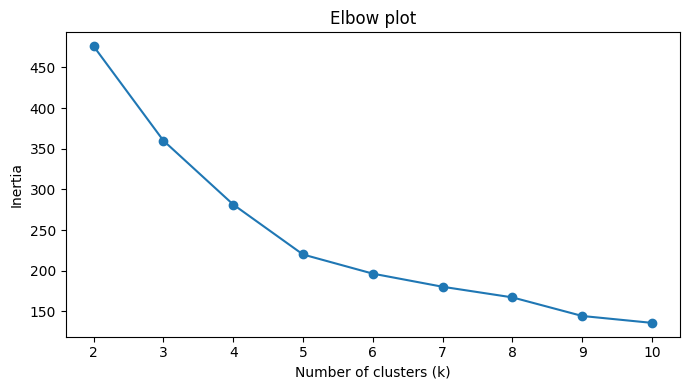

In [12]:
# elbow plot to choose k
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow plot")
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

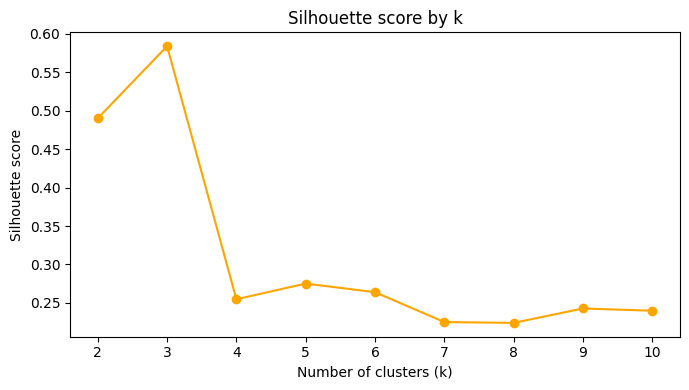

Best k by silhouette score: 3 (score=0.5839)


In [13]:
# silhouette score to choose k
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), silhouette_scores, marker="o", color="orange")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score by k")
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print(f"Best k by silhouette score: {best_k} (score={max(silhouette_scores):.4f})")

**Which K to choose?**  
Elbow plot suggests k=5, but it focuses on inertia which tends to keep adding clusters to reduce within-cluster variance, and the elbow is not that clear in our case.  
Silhouette score suggests k=3, it focuses on both cohesion and separation  
We will select **K = 3** because we prefer more distinct clusters  


In [14]:
# centroids for K=3
import pandas as pd

km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
km3.fit(X_scaled)
centroids = pd.DataFrame(
    scaler.inverse_transform(km3.cluster_centers_),
    columns=FEATURES
)
centroids.index.name = "cluster"
display(centroids.round(3))

,avg_hourly_volume,peak_ratio,offday_workday_ratio,weather_sensitivity,seasonal_amplitude
cluster,,,,,
0,17.515,0.380,0.691,0.780,1.872
1,154.271,0.335,0.622,1.002,1.608
2,27.729,0.231,1.555,0.669,4.643


**Cluster 0:** Commute stations with low volume, high peak ratio and low offday_workday_ratio, sensitive to weather and season  
**Cluster 1:** Commute stations with huge volume, high peak ratio and low offday_workday_ratio, less sensitive to weather  
**Cluster 2:** Leisure stations, with low peak ratio and high offday_workday_ratio, very sensitive to weather and season

In [15]:
# fit final K-means with K=3, reuse km3 already fitted above
labels = km3.predict(X_scaled)

station_profiles_clustered = station_profiles.with_columns(
    pl.Series("cluster", labels)
)

print(station_profiles_clustered.group_by("cluster").agg(pl.len().alias("n_stations")).sort("cluster"))
with pl.Config(tbl_rows=-1):
    display(station_profiles_clustered)

shape: (3, 2)
┌─────────┬────────────┐
│ cluster ┆ n_stations │
│ ---     ┆ ---        │
│ i32     ┆ u32        │
╞═════════╪════════════╡
│ 0       ┆ 127        │
│ 1       ┆ 4          │
│ 2       ┆ 9          │
└─────────┴────────────┘


site_id,avg_hourly_volume,peak_ratio,offday_workday_ratio,weather_sensitivity,seasonal_amplitude,cluster
i64,f64,f64,f64,f64,f64,i32
1,16.393196,0.396579,0.704524,0.75182,1.809123,0
2,33.207101,0.422019,0.544329,0.884357,1.340544,0
3,29.625414,0.41194,0.546835,0.861842,1.457254,0
4,7.159036,0.361847,0.860876,0.677729,2.55728,0
5,7.744834,0.323245,0.874849,0.713118,2.31321,0
6,14.949423,0.506026,0.479631,0.710461,1.479459,0
7,13.84005,0.357055,0.491389,0.919236,1.556696,0
8,14.639114,0.461006,0.476603,0.737646,1.541189,0
9,16.501085,0.354749,0.504058,0.785715,1.589291,0


In [16]:
# join longitude and latitude from df (one row per site_id is enough)
site_coords = train_pivot.select(["site_id", "long", "lat", "naam"]).unique("site_id")

station_profiles_clustered = station_profiles_clustered.join(
    site_coords,
    on="site_id",
    how="left",
)

display(station_profiles_clustered)

site_id,avg_hourly_volume,peak_ratio,offday_workday_ratio,weather_sensitivity,seasonal_amplitude,cluster,long,lat,naam
i64,f64,f64,f64,f64,f64,i32,f64,f64,str
1,16.393196,0.396579,0.704524,0.75182,1.809123,0,4.456122,50.916183,"""Machelen"""
2,33.207101,0.422019,0.544329,0.884357,1.340544,0,4.47169,51.27512,"""Brasschaat 2"""
3,29.625414,0.41194,0.546835,0.861842,1.457254,0,4.47222,51.27503,"""Brasschaat 1"""
4,7.159036,0.361847,0.860876,0.677729,2.55728,0,5.19011,51.16023,"""Balen 1"""
5,7.744834,0.323245,0.874849,0.713118,2.31321,0,5.19003,51.16018,"""Balen 2"""
…,…,…,…,…,…,…,…,…,…
138,80.826498,0.330819,0.622049,0.734881,2.044734,0,5.3422472,50.940532,"""Hasselt-Kempische brug"""
139,20.139096,0.25112,1.359735,0.572824,4.977561,2,5.3819796,51.064427,"""Houthalen-Helchteren"""
140,68.896721,0.291873,0.599188,0.884986,1.34306,0,5.3438616,50.930004,"""Hasselt ring"""


In [17]:
# check which sites are new in the test set (not in train)
train_sites = set(train_df["site_id"].unique().to_list())
test_sites  = set(test_df["site_id"].unique().to_list())

new_sites = sorted(test_sites - train_sites)
print(f"New sites in test set ({len(new_sites)}): {new_sites}")

New sites in test set (9): [123, 145, 146, 147, 148, 149, 150, 151, 152]


In [18]:
station_profiles_clustered.write_csv("../Cluster/station_profiles_clustered.csv")
print("saved to Cluster/station_profiles_clustered.csv")

saved to Cluster/station_profiles_clustered.csv
